In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ranking_dataset.csv')
print(df.head())

   val_0  val_1  val_2  val_3  val_4  val_5  val_6  val_7  val_8  val_9  \
0    542     67    876    414     26    335    620    924    950    113   
1    378     14    210    954    231    572    315    295    567    706   
2    749    876     73    111    899    213    541    769    287    219   
3    372    880    475    329    733    564    739    376    632     10   
4    186    822    577    519    707    123    143    294    693    677   

   rank_0  rank_1  rank_2  rank_3  rank_4  rank_5  rank_6  rank_7  rank_8  \
0       5       1       7       4       0       3       6       8       9   
1       5       0       1       9       2       7       4       3       6   
2       6       8       0       1       9       2       5       7       4   
3       2       9       4       1       7       5       8       3       6   
4       2       9       5       4       8       0       1       3       7   

   rank_9  
0       2  
1       8  
2       3  
3       0  
4       6  


In [3]:
# Importing required modules (I will import another modules if needed later)
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np
import random

In [4]:
## Forming test , train and validation datasets
X=df.iloc[:,0:10].copy()
y=df.iloc[:,10:].copy()

X_norm_zscore = X.sub(X.mean(axis=1), axis=0).div(X.std(axis=1), axis=0)
X_norm = X_norm_zscore.copy()

X_arr=np.array(X_norm)
y_arr=np.array(y)

X_train , X_t ,y_train, y_t = train_test_split(
    X_arr,y_arr,test_size=0.4,random_state=42
)
X_val,X_test,y_val,y_test=train_test_split(
    X_t,y_t,test_size=0.5,random_state=42
)

X_train=torch.tensor(X_train).float()
y_train=torch.tensor(y_train).long()
X_val=torch.tensor(X_val).float()
y_val=torch.tensor(y_val).long()
X_test=torch.tensor(X_test).float()
y_test=torch.tensor(y_test).long()

print(X_test.shape , y_test.shape)
X_test1=X_test
y_test1=y_test
print(X_test1.shape , y_test1.shape)

torch.Size([2000, 10]) torch.Size([2000, 10])
torch.Size([2000, 10]) torch.Size([2000, 10])


In [5]:
# MLP model
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.input=1
    self.output=10
    self.fc1=nn.Linear(self.input,256)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(256,self.output)
  def forward(self,x):
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    return x

In [6]:
model1=MLP()
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model1.parameters(),lr=0.0001)

In [7]:
## Training loop
model1.train()
for epoch in range(5):
  total_loss=0
  for i in range(len(X_train)):
    for j in range(len(X_train[0])):
      optimizer.zero_grad()
      predictions=model1(X_train[i][j].unsqueeze(0))
      loss=criterion(predictions,y_train[i][j])
      loss.backward()
      optimizer.step()
      total_loss+=loss.item()
  print(f"Epoch {epoch+1} loss : {total_loss}")

Epoch 1 loss : 62330.22343985399
Epoch 2 loss : 59119.3787972313
Epoch 3 loss : 59083.88531283534
Epoch 4 loss : 59067.050032565516
Epoch 5 loss : 59056.76981547108


In [8]:
# Define a path to save model1
model1_save_path = '/content/drive/MyDrive/mlp_model.pth'

# Save the state dictionary of model1
torch.save(model1.state_dict(), model1_save_path)

print(f"Model1 parameters saved to: {model1_save_path}")

Model1 parameters saved to: /content/drive/MyDrive/mlp_model.pth


In [9]:
#Testing loop
model1.eval()
acc=0
tot=0
for i in range(len(X_test)):
  for j in range(len(X_test[0])):
    predict=model1(X_test[i][j].unsqueeze(0))
    acc+=(torch.argmax(predict)==y_test[i][j])
    tot+=1
print(f"Accuracy of MLP model : {acc*100/tot}")



Accuracy of MLP model : 54.60499954223633


In [10]:
## LSTM model
class Encoder(nn.Module):
  def __init__(self, input_size=1, hidden_size=256):
    super().__init__()
    self.lstm=nn.LSTM(input_size, hidden_size, batch_first=True)
  def forward(self,x):
    _,(hidden,cell)=self.lstm(x)
    return hidden , cell


class Decoder(nn.Module):
  def __init__(self, output_dim=10, embedding_dim=256, lstm_hidden_size=256):
    super().__init__()
    self.embedding = nn.Embedding(output_dim + 1, embedding_dim)
    self.lstm = nn.LSTM(embedding_dim, lstm_hidden_size, batch_first=True)
    self.fc = nn.Linear(lstm_hidden_size, output_dim)
    self.output_dim = output_dim



  # LLM was used to get the idea that I need to use embeddings and code it

  def forward(self, input_token, hidden, cell):
    # input_token is expected to be (batch_size,) e.g., (1,) and long type
    embedded = self.embedding(input_token) # Result: (batch_size, embedding_dim) e.g., (1, 256) and float32
    # Unsqueeze to (batch_size, 1, embedding_dim) for batch_first=True LSTM
    embedded = embedded.unsqueeze(1) # Result: (batch_size, 1, embedding_dim) e.g., (1, 1, 256)

    # Pass embedded token and hidden states to LSTM
    output, (hidden, cell) = self.lstm(embedded, (hidden, cell))

    # Squeeze the sequence length dimension (which is 1) before passing to FC layer
    prediction = self.fc(output.squeeze(1)) # Output: (batch_size, output_dim)
    return prediction, hidden, cell

In [11]:
# Seq2Seq model class
class Seq2Seq (nn.Module):
  def __init__(self,encoder,decoder):
    super().__init__()
    self.encoder=encoder
    self.decoder=decoder
    self.SOS=torch.tensor(10, dtype=torch.long).unsqueeze(0)
  def forward(self,src,trg):
    hidden_encoder , cell_encoder=self.encoder(src)
    input=self.SOS
    output_logits=[]
    # The code for storing logits is done using LLM only here later all was written by me
    for i in range(len(trg)):
      out,hidden,cell=self.decoder(input,hidden_encoder,cell_encoder)
      output_logits.append(out)
      hidden_encoder=hidden
      cell_encoder=cell
      input=trg[i].unsqueeze(0)
    return torch.stack(output_logits)

In [12]:
model2 =Seq2Seq(encoder=Encoder(),decoder=Decoder())
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model2.parameters(),lr=0.00001) # Reduced learning rate

In [14]:
# Training loop
model2.train()
for epoch in range(10):
  total_loss=0.0
  optimizer.zero_grad()
  for i in range(len(X_train)):
    prediction=model2(X_train[i].unsqueeze(0).unsqueeze(-1),y_train[i])
    # Squeeze the singleton batch dimension from prediction before passing to criterion
    loss=criterion(prediction.squeeze(1),y_train[i])
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"Epoch {epoch+1} loss : {total_loss}")

Epoch 1 loss : 7877.086327672005
Epoch 2 loss : 7623.655799984932
Epoch 3 loss : 7260.014317750931
Epoch 4 loss : 6890.545405387878
Epoch 5 loss : 6468.135447084904
Epoch 6 loss : 6141.5586569309235
Epoch 7 loss : 5787.830455303192
Epoch 8 loss : 5455.0228735506535
Epoch 9 loss : 5105.73373863101
Epoch 10 loss : 4874.206194192171


In [15]:
# Define a path to save model2
model2_save_path = '/content/drive/MyDrive/lstm_seq2seq_model.pth'

# Save the state dictionary of model2
torch.save(model2.state_dict(), model2_save_path)

print(f"Model2 parameters saved to: {model2_save_path}")

Model2 parameters saved to: /content/drive/MyDrive/lstm_seq2seq_model.pth


In [16]:
# Evaluation loop
model2.eval()
correct_predictions = 0
total_predictions = 0
sequence_length = y_test.shape[1]
with torch.no_grad():
  for i in range(len(X_test)):
    src = X_test[i].unsqueeze(0).unsqueeze(-1)
    trg_true = y_test[i]
    hidden_encoder , cell_encoder = model2.encoder(src)
    decoder_input = model2.SOS

    for t in range(sequence_length):
      output , hidden_encoder , cell_encoder = model2.decoder(decoder_input, hidden_encoder, cell_encoder)
      predicted_token = torch.argmax(output, dim=1)
      if predicted_token.item() == trg_true[t].item():
          correct_predictions += 1
      total_predictions += 1
      decoder_input = predicted_token
accuracy = (correct_predictions / total_predictions) * 100
print(f"Accuracy of LSTM model (Seq2Seq without teacher forcing): {accuracy:.2f}%")

Accuracy of LSTM model (Seq2Seq without teacher forcing): 28.52%


In [17]:
## Forming batches
training_dataset=torch.utils.data.TensorDataset(X_train,y_train)
train_loader=torch.utils.data.DataLoader(training_dataset,16)

In [18]:
# Positional encoding
class Positional_Encoding(nn.Module):
  def __init__(self):
    super().__init__()
    pe=torch.zeros(10,64)
    position=torch.arange(0,10,dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, 64, 2).float() * -(torch.log(torch.tensor(10000.0)) / 64))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer('pe',pe)
  def forward(self,x):
    return x+(self.pe).unsqueeze(0)

In [19]:
## Bi Directional Self Attention
class Self_attention(nn.Module):
  def __init__(self,input_dim=64,head_dim=128):
    super().__init__()
    self.w_q=nn.Linear(input_dim,head_dim)
    self.w_k=nn.Linear(input_dim,head_dim)
    self.w_v=nn.Linear(input_dim,head_dim)
    self.head_dim=head_dim
    self.attention_weights = None
  def forward(self,x):
    Q=self.w_q(x)
    K=self.w_k(x)
    V=self.w_v(x)
    self.attention_weights=torch.matmul(Q,K.transpose(-2,-1))/self.head_dim**0.5
    output=torch.matmul(self.attention_weights,V)
    return output

In [20]:
# Feed Forward loop
class Feed_forward_loop(nn.Module):
  def __init__(self,input_dim=128,output_dim=10,hidden_dim=128):
    super().__init__()
    self.fc1=nn.Linear(input_dim,hidden_dim)
    self.relu=nn.ReLU()
    self.fc2=nn.Linear(hidden_dim,output_dim)
  def forward(self,x):
    # Optimized for batched input, no explicit loop needed
    x=self.fc1(x)
    x=self.relu(x)
    x=self.fc2(x)
    return x

In [21]:
# Encoder only self attention class
class Encoder_only_self_atten(nn.Module):
  def __init__(self,position_enc,attention,feed_forward):
    super().__init__()
    self.attention=attention
    self.position_enc=position_enc
    self.feed_forward=feed_forward
    self.internal_projection=nn.Linear(1,64)
    self.relu=nn.ReLU()
    self.projection=nn.Linear(64,128)
    self.norm=nn.LayerNorm(128)
    self.prob=nn.Linear(10,1)
  def forward(self,x):
    x=self.internal_projection(x)
    x=self.relu(x)
    x=self.position_enc(x)
    attention_scores=self.attention(x)
    residual_connection=self.norm(attention_scores+self.projection(x))
    predictions=self.feed_forward(residual_connection)
    return predictions

In [22]:
model3=Encoder_only_self_atten(Positional_Encoding(),Self_attention(),Feed_forward_loop())
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model3.parameters(),lr=0.0001)

In [23]:
## Training loop
training_losses=[]
validation_losses=[]
validation_dataset=torch.utils.data.TensorDataset(X_val,y_val)
validation_loader=torch.utils.data.DataLoader(validation_dataset)
for epoch in range(50):
  model3.train()
  total_loss=0
  val_loss=0
  for X_batch , y_batch in train_loader:
    optimizer.zero_grad()
    input_batch=X_batch.unsqueeze(-1)
    predictions_batch=model3(input_batch)
    loss = criterion(predictions_batch.view(-1, predictions_batch.shape[-1]), y_batch.view(-1))
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()

  model3.eval()
  with torch.no_grad():
    for X_val_batch , y_val_batch in validation_loader:
      input_batch_val=X_val_batch.unsqueeze(-1)
      prediction_val_batch=model3(input_batch_val)
      loss_val=criterion(prediction_val_batch.view(-1,prediction_val_batch.shape[-1]),y_val_batch.view(-1))
      val_loss+=loss_val.item()
  training_losses.append(total_loss/(6000))
  print(f"Epoch {epoch+1} : {total_loss}")
  validation_losses.append(val_loss/6000)
  print(f"Val loss {epoch+1} : {val_loss}")

Epoch 1 : 530.9127885103226
Val loss 1 : 2043.2298597097397
Epoch 2 : 360.36517173051834
Val loss 2 : 1809.8862273693085
Epoch 3 : 332.93888288736343
Val loss 3 : 1683.4354600012302
Epoch 4 : 308.83085411787033
Val loss 4 : 1574.7216206789017
Epoch 5 : 285.2273547053337
Val loss 5 : 1498.0128394663334
Epoch 6 : 267.2079557776451
Val loss 6 : 1398.2598405480385
Epoch 7 : 255.61897212266922
Val loss 7 : 1324.1074391901493
Epoch 8 : 245.62384194135666
Val loss 8 : 1277.1257207989693
Epoch 9 : 234.672607421875
Val loss 9 : 1240.8054180592299
Epoch 10 : 223.24421176314354
Val loss 10 : 1177.2871661186218
Epoch 11 : 212.7416252195835
Val loss 11 : 1111.6830684244633
Epoch 12 : 203.73844534158707
Val loss 12 : 1061.552881643176
Epoch 13 : 196.2448962032795
Val loss 13 : 1020.7369864881039
Epoch 14 : 189.40651816129684
Val loss 14 : 987.9837247952819
Epoch 15 : 183.23250484466553
Val loss 15 : 962.7180363833904
Epoch 16 : 178.02596306800842
Val loss 16 : 944.7524026110768
Epoch 17 : 173.836010

In [24]:
# Evaluation loop
model3.eval()
testing_dataset=torch.utils.data.TensorDataset(X_test1,y_test1)
testing_loader=torch.utils.data.DataLoader(testing_dataset, batch_size=16)
correct_pred=0
total_pred=0
# print(len(testing_dataset) , len(X_test1) , len(y_test1))
# print(len(testing_loader))
with torch.no_grad():
    for X_batch, y_batch in testing_loader:
      # print(X_batch.shape , y_batch.shape)
      input_batch = X_batch.unsqueeze(-1)
      predictions_batch = model3(input_batch)
      predicted_ranks = torch.argmax(predictions_batch, dim=2)
      prediction_ranks_flattened= predicted_ranks.view(-1)
      y_batch=y_batch.view(-1)
      for t in range(len(y_batch)):
        correct_pred += (prediction_ranks_flattened[t] == y_batch[t])
        total_pred += 1
print(f"Accuracy : {(correct_pred / total_pred) * 100:.2f}")
print(correct_pred , total_pred)

Accuracy : 87.37
tensor(17474) 20000


In [26]:
# Define a path to save model3
model3_save_path = '/content/drive/MyDrive/encoder_only_attention_model.pth'

# Save the state dictionary of model3
torch.save(model3.state_dict(), model3_save_path)

print(f"Model3 parameters saved to: {model3_save_path}")

Model3 parameters saved to: /content/drive/MyDrive/encoder_only_attention_model.pth


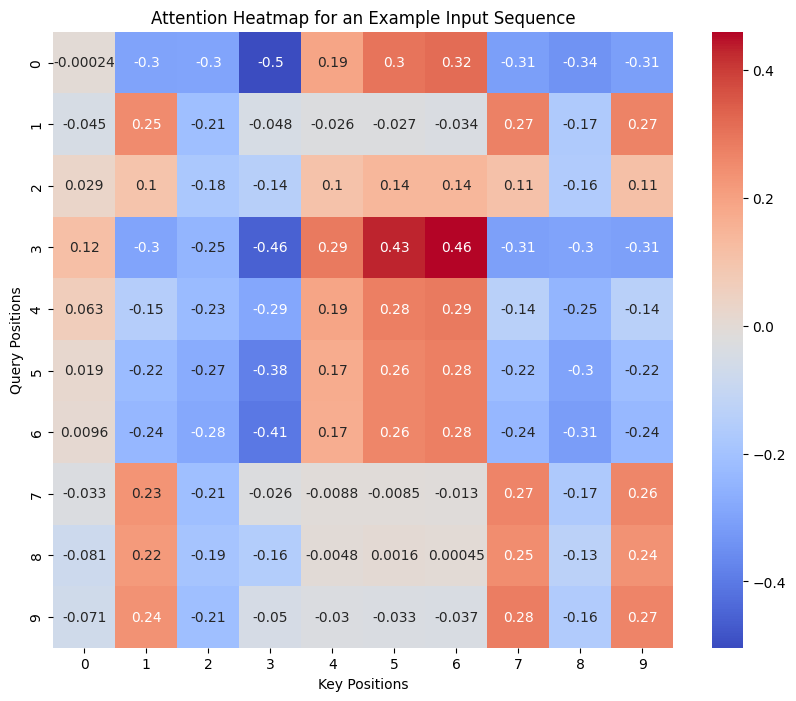

In [30]:
## Used LLM to know how to extract attention weights and writing this code I made a change in cmap
import matplotlib.pyplot as plt
import seaborn as sns

model3.eval()
input=X_test[0].unsqueeze(0).unsqueeze(-1)
output=model3(input)
attention_weights = model3.attention.attention_weights.detach().squeeze(0).cpu().numpy()
plt.figure(figsize=(10, 8))
sns.heatmap(attention_weights, cmap='coolwarm', annot=True)
plt.title('Attention Heatmap for an Example Input Sequence')
plt.xlabel('Key Positions')
plt.ylabel('Query Positions')
plt.show()

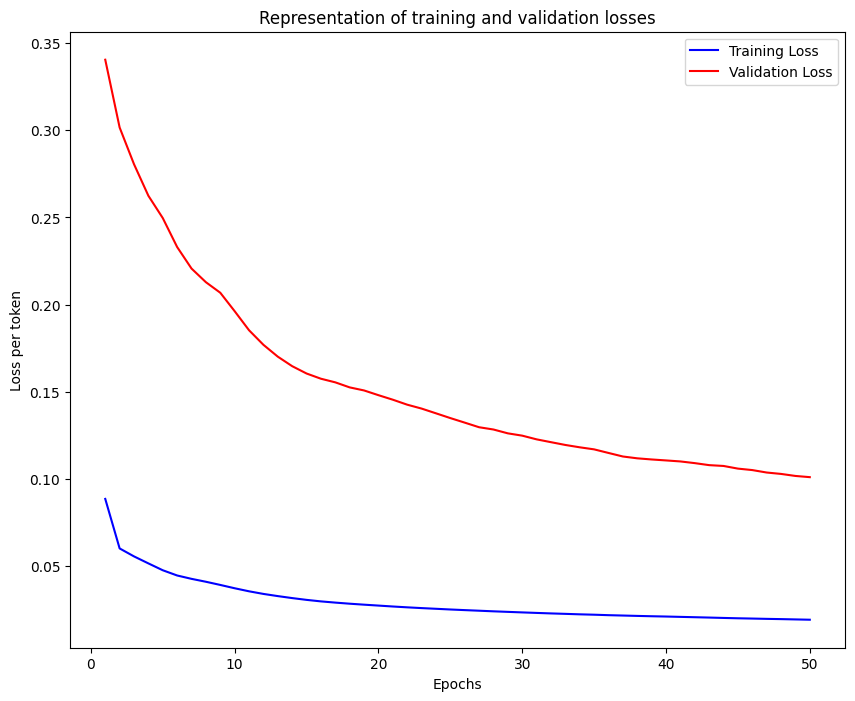

In [31]:
plt.figure(figsize=(10,8))
plt.plot([i+1 for i in range(50)],training_losses, color='blue', label='Training Loss')
plt.plot([i+1 for i in range(50)],validation_losses, color='red', label='Validation Loss')
plt.title("Representation of training and validation losses")
plt.xlabel("Epochs")
plt.ylabel("Loss per token")
plt.legend()
plt.show()

In [32]:
import numpy as np
# Demo model
input_seq=[1,2,3,4,5,6,7,8,9,10]
sum=0
for i in input_seq:
  sum+=i
mean=sum/len(input_seq)
std_sum=0
for i in input_seq:
  std_sum+=(i-mean)**2
std=np.sqrt(std_sum/len(input_seq))
input_norm=(np.array(input_seq)-mean)/std
input_tensor=torch.tensor(input_norm).unsqueeze(0).unsqueeze(-1)
predictions=model3(input_tensor.float())
predict=torch.argmax(predictions,dim=2)
print(predict)

tensor([[0, 1, 2, 2, 4, 5, 6, 7, 8, 9]])
